# Phase 2: Exploratory Data Analysis (EDA)

**Course**: Data Science and AI - Sharif University  
**Team**: Bahman Farhadian, Mahdi Samadi Azar  
**Dataset**: Divar Real Estate Advertisements (1M records, cleaned)

---

## Objective

Perform comprehensive statistical analysis to understand the data distributions, relationships between variables, and extract meaningful insights for business decision-making.

> **Instructor's guidance**: This phase focuses on statistical EDA - distributions, correlations, scatter plots, and notable findings. Keep visualizations simple and interpretable for non-technical stakeholders.

## What This Notebook Covers

1. **Data Loading & Feature Engineering** - Load cleaned data and create analytical features
2. **Univariate Analysis (Numerical)** - Distribution of prices, sizes, and key metrics
3. **Univariate Analysis (Categorical)** - City, property type, and category distributions
4. **Bivariate Analysis** - Correlations and relationships between variables
5. **Price Analysis by Segments** - Regional and property-type price variations
6. **Temporal Analysis** - Market trends over time
7. **Rental Market Overview** - Brief analysis of rental listings
8. **Statistical Summary & Key Findings** - Insights for subsequent phases

## Business Questions We Will Answer

- Which cities have the highest real estate prices?
- What is the typical price range for different property types?
- How do prices vary by building size and number of rooms?
- Is there a significant difference between agency and personal listings?
- How has the market evolved over time?
- What features are most correlated with property prices?

---

## 1. Setup and Library Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Persian text display fix
import arabic_reshaper
from bidi.algorithm import get_display

def fix_persian(text):
    """Reshape Persian/Arabic text for correct display in matplotlib."""
    if pd.isna(text):
        return 'Unknown/NULL'
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Color palette
COLORS = {
    'primary': '#2ecc71', 'secondary': '#3498db', 'accent': '#e74c3c',
    'neutral': '#95a5a6', 'sell': '#27ae60', 'rent': '#3498db'
}

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 2. Project Structure

In [42]:
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_PATH = PROJECT_ROOT / 'notebooks' / 'outputs' / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures path: {FIGURES_PATH}")

Project root: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar
Figures path: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/notebooks/outputs/figures


## 3. Load Cleaned Data

In [43]:
DATA_FILE = DATA_PROCESSED / 'cleaned_data.csv'
print(f"Loading: {DATA_FILE}")
df = pd.read_csv(DATA_FILE, low_memory=False)
print(f"\n✓ Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loading: /home/bahman/b/repositories/pydsai_divar_real_estate_analysis_hossein_hamzehi_mahdi_samdi_azar/data/processed/cleaned_data.csv

✓ Dataset: 1,000,000 rows, 65 columns


In [44]:
# Verify Phase 1 columns
phase1_cols = ['listing_type', 'price_outlier', 'size_outlier']
for col in phase1_cols:
    if col in df.columns:
        print(f"✓ {col} present")
    else:
        print(f"⚠ {col} missing")

print("\nListing Type Distribution:")
print(df['listing_type'].value_counts())

✓ listing_type present
✓ price_outlier present
✓ size_outlier present

Listing Type Distribution:
listing_type
sell     597569
rent     383028
other     19403
Name: count, dtype: int64


---

## 4. Feature Engineering

### 4.1 Create All Analytical Features

We create all features BEFORE creating any filtered subsets to ensure consistency.

In [45]:
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# 1. Ensure numeric types
df['price_value'] = pd.to_numeric(df['price_value'], errors='coerce')
df['building_size'] = pd.to_numeric(df['building_size'], errors='coerce')
df['rent_value'] = pd.to_numeric(df['rent_value'], errors='coerce')
df['credit_value'] = pd.to_numeric(df['credit_value'], errors='coerce')
print("✓ Numeric conversion complete")

# 2. Price per square meter
valid_mask = (df['price_value'] > 0) & (df['building_size'] > 0)
df['price_per_sqm'] = np.nan
df.loc[valid_mask, 'price_per_sqm'] = df.loc[valid_mask, 'price_value'] / df.loc[valid_mask, 'building_size']
print(f"✓ price_per_sqm: {df['price_per_sqm'].notna().sum():,} records")

# 3. Flag outliers (reasonable range: 5M - 500M Tomans/sqm)
df['price_sqm_outlier'] = ((df['price_per_sqm'] < 5_000_000) | 
                           (df['price_per_sqm'] > 500_000_000)).fillna(False)
print(f"✓ Outliers flagged: {df['price_sqm_outlier'].sum():,}")

# 4. Temporal features
if 'created_at_month' in df.columns:
    df['created_at_month'] = pd.to_datetime(df['created_at_month'], errors='coerce')
    df['year'] = df['created_at_month'].dt.year
    df['month'] = df['created_at_month'].dt.month
    df['year_month'] = df['created_at_month'].dt.to_period('M')
    print("✓ Temporal features created")

# 5. Price category
def categorize_price(price):
    if pd.isna(price): return 'Unknown'
    if price < 30_000_000: return 'Budget (<30M)'
    if price < 80_000_000: return 'Mid-range (30-80M)'
    if price < 150_000_000: return 'Upper-mid (80-150M)'
    if price < 300_000_000: return 'Premium (150-300M)'
    return 'Luxury (300M+)'

df['price_category'] = df['price_per_sqm'].apply(categorize_price)
print("✓ Price categories created")
print("\n" + "=" * 60)

FEATURE ENGINEERING
✓ Numeric conversion complete
✓ price_per_sqm: 565,163 records
✓ Outliers flagged: 87,817
✓ Temporal features created
✓ Price categories created



### 4.2 Create Analysis Subsets

In [46]:
# Clean sell dataset (filtered for analysis)
df_sell_clean = df[
    (df['listing_type'] == 'sell') & 
    (df['price_per_sqm'].notna()) & 
    (~df['price_sqm_outlier'])
].copy()

df_rent = df[df['listing_type'] == 'rent'].copy()

print(f"✓ Clean sell dataset: {len(df_sell_clean):,} records")
print(f"✓ Rental dataset: {len(df_rent):,} records")
print(f"\nPrice Category Distribution:")
print(df_sell_clean['price_category'].value_counts())

✓ Clean sell dataset: 477,340 records
✓ Rental dataset: 383,028 records

Price Category Distribution:
price_category
Budget (<30M)          217018
Mid-range (30-80M)     183889
Upper-mid (80-150M)     51808
Premium (150-300M)      19966
Luxury (300M+)           4659
Name: count, dtype: int64


---

## 5. Dataset Overview

In [47]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal Records: {len(df):,}")
print(f"\n📊 Listing Type Breakdown:")
for lt, count in df['listing_type'].value_counts().items():
    print(f"  {lt.capitalize():10s}: {count:>10,} ({count/len(df)*100:.1f}%)")

print(f"\n📈 Key Columns Availability:")
for col in ['price_value', 'building_size', 'rooms_count', 'city_slug', 'cat3_slug', 'user_type']:
    if col in df.columns:
        pct = df[col].notna().sum() / len(df) * 100
        print(f"  {col:20s}: {pct:>5.1f}% available")

DATASET OVERVIEW

Total Records: 1,000,000

📊 Listing Type Breakdown:
  Sell      :    597,569 (59.8%)
  Rent      :    383,028 (38.3%)
  Other     :     19,403 (1.9%)

📈 Key Columns Availability:
  price_value         :  56.8% available
  building_size       :  98.0% available
  rooms_count         :  84.6% available
  city_slug           : 100.0% available
  cat3_slug           : 100.0% available
  user_type           :  28.9% available


In [48]:
# Summary statistics for key numerical columns
key_numerical = ['price_value', 'building_size', 'price_per_sqm', 'rent_value', 'credit_value']
key_numerical = [col for col in key_numerical if col in df.columns]

summary = df[key_numerical].describe().T
summary['non_null'] = df[key_numerical].notna().sum()
summary['null_pct'] = (1 - summary['non_null'] / len(df)) * 100
summary

,count,mean,std,min,25%,50%,75%,max,non_null,null_pct
price_value,568346.00,17365370640.35,587873885223.63,0.00,1400000000.00,2840000000.00,5900000000.00,99999999999999.00,568346,43.17
building_size,980394.00,4440.65,136711.84,1.00,75.00,103.00,165.00,10000000.00,980394,1.96
price_per_sqm,565163.00,142275314.96,7215467040.97,0.00,12800000.00,27800000.00,50602409.64,3333333333333.30,565163,43.48
rent_value,351322.00,41022993841.50,3807534359773.34,0.00,111111.00,5000000.00,12000000.00,999999999999999.00,351322,64.87
credit_value,352095.00,48720843306.65,4341345683527.13,0.00,100000000.00,250000000.00,500000000.00,999999999999999.00,352095,64.79


---

## 6. Univariate Analysis - Numerical Variables

### 6.1 Price Distribution (Sell Listings)

In [49]:
print("=" * 60)
print("PRICE DISTRIBUTION ANALYSIS")
print("=" * 60)

sell_prices = df[(df['listing_type'] == 'sell') & (df['price_value'] > 0)]['price_value'].dropna()

print(f"\nSell listings with prices: {len(sell_prices):,}")
print(f"\nPrice Statistics (Tomans):")
print(f"  Mean:     {sell_prices.mean():>18,.0f} ({sell_prices.mean()/1e9:.2f}B)")
print(f"  Median:   {sell_prices.median():>18,.0f} ({sell_prices.median()/1e9:.2f}B)")
print(f"  Std Dev:  {sell_prices.std():>18,.0f}")
print(f"  Skewness: {sell_prices.skew():>18,.2f}")

print(f"\nPercentiles (Billion Tomans):")
for p in [5, 25, 50, 75, 95]:
    print(f"  {p:3d}th: {sell_prices.quantile(p/100)/1e9:>10,.2f}B")

PRICE DISTRIBUTION ANALYSIS

Sell listings with prices: 565,190

Price Statistics (Tomans):
  Mean:         17,447,858,310 (17.45B)
  Median:        2,850,000,000 (2.85B)
  Std Dev:     589,510,669,952
  Skewness:             111.72

Percentiles (Billion Tomans):
    5th:       0.30B
   25th:       1.40B
   50th:       2.85B
   75th:       5.92B
   95th:      21.00B


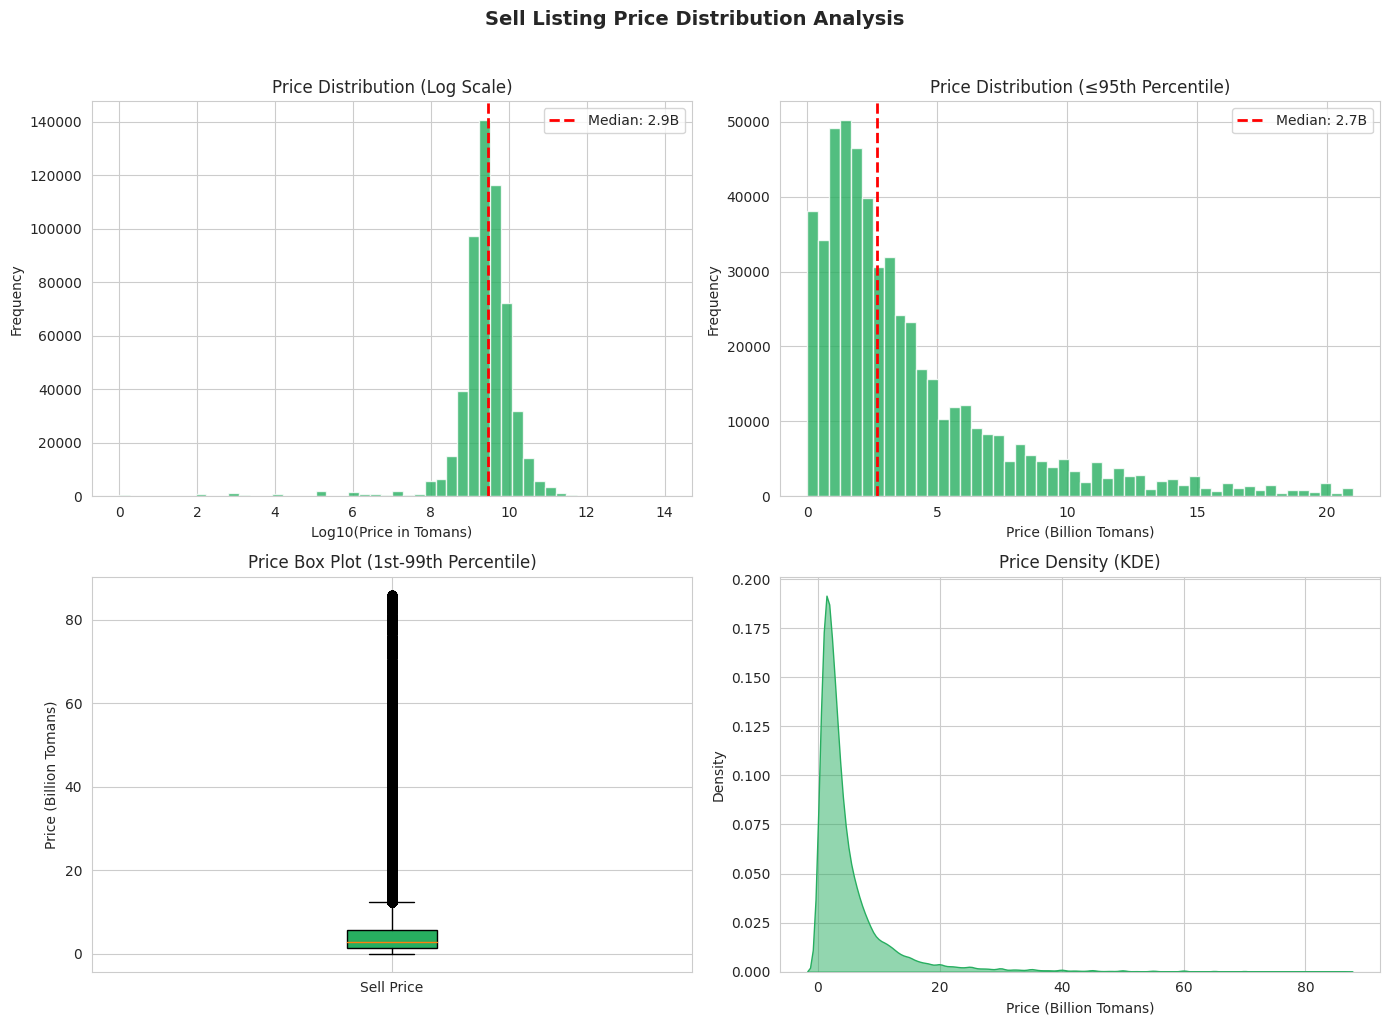

In [50]:
# Price Distribution Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Log scale histogram
axes[0, 0].hist(np.log10(sell_prices), bins=50, color=COLORS['sell'], edgecolor='white', alpha=0.8)
axes[0, 0].axvline(x=np.log10(sell_prices.median()), color='red', linestyle='--', lw=2, 
                   label=f'Median: {sell_prices.median()/1e9:.1f}B')
axes[0, 0].set_xlabel('Log10(Price in Tomans)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution (Log Scale)')
axes[0, 0].legend()

# 2. Trimmed histogram
p95 = sell_prices.quantile(0.95)
sell_trimmed = sell_prices[sell_prices <= p95]
axes[0, 1].hist(sell_trimmed / 1e9, bins=50, color=COLORS['sell'], edgecolor='white', alpha=0.8)
axes[0, 1].axvline(x=sell_trimmed.median()/1e9, color='red', linestyle='--', lw=2,
                   label=f'Median: {sell_trimmed.median()/1e9:.1f}B')
axes[0, 1].set_xlabel('Price (Billion Tomans)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Price Distribution (≤95th Percentile)')
axes[0, 1].legend()

# 3. Box plot (trimmed)
sell_box = sell_prices[(sell_prices >= sell_prices.quantile(0.01)) & 
                        (sell_prices <= sell_prices.quantile(0.99))]
bp = axes[1, 0].boxplot(sell_box / 1e9, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor(COLORS['sell'])
axes[1, 0].set_ylabel('Price (Billion Tomans)')
axes[1, 0].set_title('Price Box Plot (1st-99th Percentile)')
axes[1, 0].set_xticklabels(['Sell Price'])

# 4. KDE
sns.kdeplot(data=sell_box / 1e9, ax=axes[1, 1], color=COLORS['sell'], fill=True, alpha=0.5)
axes[1, 1].set_xlabel('Price (Billion Tomans)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Price Density (KDE)')

plt.suptitle('Sell Listing Price Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Price Per Square Meter Distribution

In [51]:
print("=" * 60)
print("PRICE PER SQUARE METER")
print("=" * 60)

price_sqm = df_sell_clean['price_per_sqm'].dropna()

print(f"\nRecords: {len(price_sqm):,}")
print(f"\nStatistics (Tomans/sqm):")
print(f"  Mean:   {price_sqm.mean()/1e6:>10,.1f}M")
print(f"  Median: {price_sqm.median()/1e6:>10,.1f}M")
print(f"  Std:    {price_sqm.std()/1e6:>10,.1f}M")

PRICE PER SQUARE METER

Records: 477,340

Statistics (Tomans/sqm):
  Mean:         49.7M
  Median:       32.1M
  Std:          54.7M


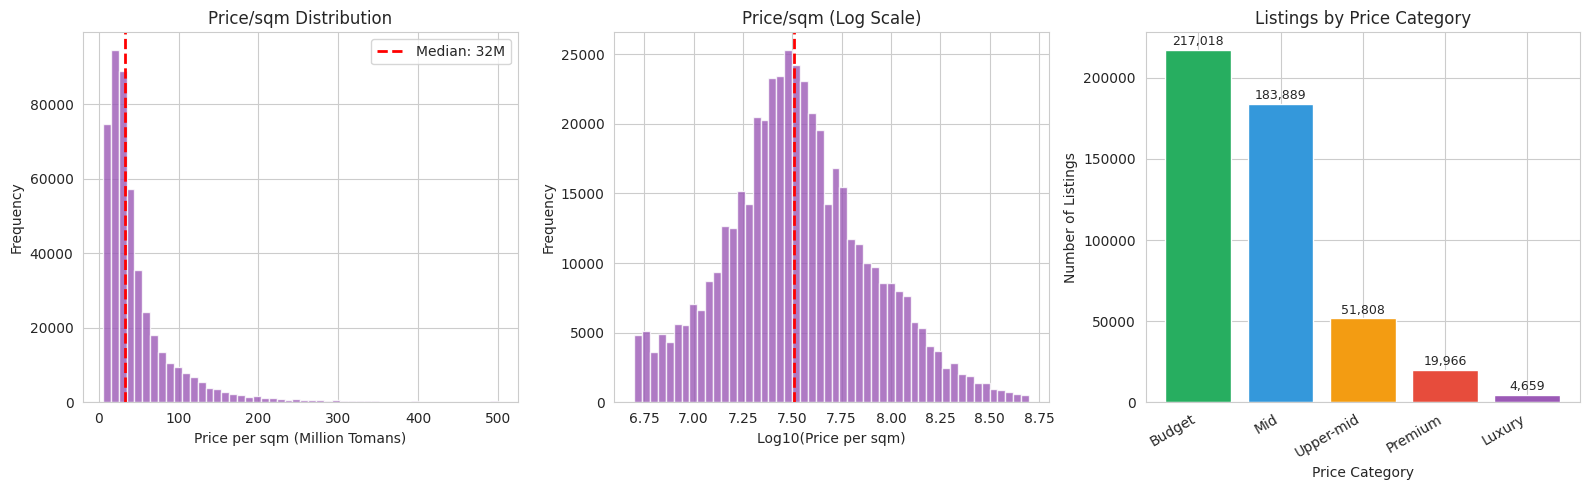

In [52]:
# Price/sqm Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram
axes[0].hist(price_sqm / 1e6, bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0].axvline(x=price_sqm.median()/1e6, color='red', linestyle='--', lw=2,
                label=f'Median: {price_sqm.median()/1e6:.0f}M')
axes[0].set_xlabel('Price per sqm (Million Tomans)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price/sqm Distribution')
axes[0].legend()

# 2. Log scale
axes[1].hist(np.log10(price_sqm), bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].axvline(x=np.log10(price_sqm.median()), color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Log10(Price per sqm)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price/sqm (Log Scale)')

# 3. By Category
cat_order = ['Budget (<30M)', 'Mid-range (30-80M)', 'Upper-mid (80-150M)', 
             'Premium (150-300M)', 'Luxury (300M+)']
cat_counts = df_sell_clean['price_category'].value_counts().reindex(cat_order).fillna(0)
colors = ['#27ae60', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']
bars = axes[2].bar(range(len(cat_counts)), cat_counts.values, color=colors)
axes[2].set_xlabel('Price Category')
axes[2].set_ylabel('Number of Listings')
axes[2].set_title('Listings by Price Category')
axes[2].set_xticks(range(len(cat_counts)))
axes[2].set_xticklabels(['Budget', 'Mid', 'Upper-mid', 'Premium', 'Luxury'], rotation=30, ha='right')
for bar, val in zip(bars, cat_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                 f'{int(val):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_price_per_sqm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Building Size Distribution

In [53]:
print("=" * 60)
print("BUILDING SIZE DISTRIBUTION")
print("=" * 60)

size_data = df['building_size'].dropna()
size_data = size_data[size_data > 0]

print(f"\nRecords: {len(size_data):,}")
print(f"\nStatistics (sqm):")
print(f"  Mean:   {size_data.mean():>10,.0f}")
print(f"  Median: {size_data.median():>10,.0f}")
print(f"  Min:    {size_data.min():>10,.0f}")
print(f"  Max:    {size_data.max():>10,.0f}")

BUILDING SIZE DISTRIBUTION

Records: 980,394

Statistics (sqm):
  Mean:        4,441
  Median:        103
  Min:             1
  Max:    10,000,000


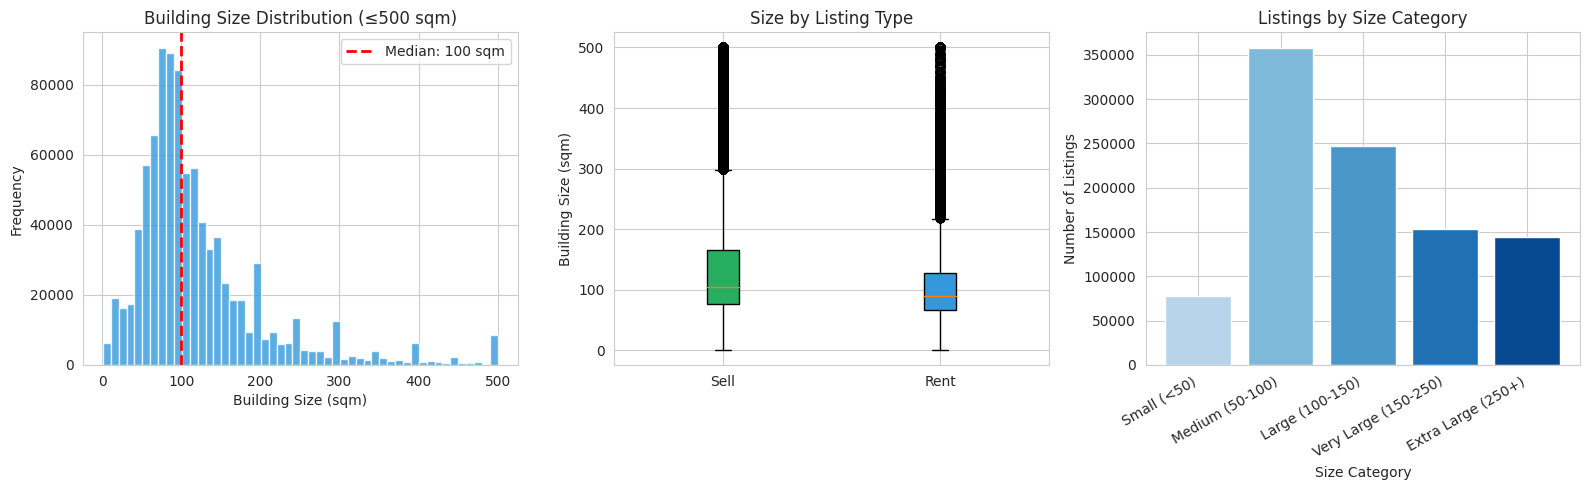

In [54]:
# Building Size Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram (≤500 sqm)
size_reasonable = size_data[size_data <= 500]
axes[0].hist(size_reasonable, bins=50, color=COLORS['secondary'], edgecolor='white', alpha=0.8)
axes[0].axvline(x=size_reasonable.median(), color='red', linestyle='--', lw=2,
                label=f'Median: {size_reasonable.median():.0f} sqm')
axes[0].set_xlabel('Building Size (sqm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Building Size Distribution (≤500 sqm)')
axes[0].legend()

# 2. Box plot by listing type
size_by_type = []
labels = []
for lt in ['sell', 'rent']:
    lt_sizes = df[(df['listing_type'] == lt) & (df['building_size'] > 0) & 
                  (df['building_size'] <= 500)]['building_size'].dropna()
    if len(lt_sizes) > 0:
        size_by_type.append(lt_sizes)
        labels.append(lt.capitalize())

bp = axes[1].boxplot(size_by_type, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], [COLORS['sell'], COLORS['rent']]):
    patch.set_facecolor(color)
axes[1].set_ylabel('Building Size (sqm)')
axes[1].set_title('Size by Listing Type')

# 3. Size categories
def cat_size(s):
    if pd.isna(s) or s <= 0: return 'Unknown'
    if s < 50: return 'Small (<50)'
    if s < 100: return 'Medium (50-100)'
    if s < 150: return 'Large (100-150)'
    if s < 250: return 'Very Large (150-250)'
    return 'Extra Large (250+)'

size_cats = df['building_size'].apply(cat_size)
cat_order = ['Small (<50)', 'Medium (50-100)', 'Large (100-150)', 'Very Large (150-250)', 'Extra Large (250+)']
cat_counts = size_cats.value_counts().reindex(cat_order).fillna(0)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(cat_counts)))
axes[2].bar(range(len(cat_counts)), cat_counts.values, color=colors)
axes[2].set_xlabel('Size Category')
axes[2].set_ylabel('Number of Listings')
axes[2].set_title('Listings by Size Category')
axes[2].set_xticks(range(len(cat_counts)))
axes[2].set_xticklabels(cat_order, rotation=30, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_building_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Rooms Count Distribution

In [55]:
if 'rooms_count' in df.columns:
    print("=" * 60)
    print("ROOMS COUNT DISTRIBUTION")
    print("=" * 60)
    
    rooms = df['rooms_count'].dropna()
    print(f"\nRecords with rooms: {len(rooms):,} ({len(rooms)/len(df)*100:.1f}%)")
    print(f"\nValue Counts:")
    print(df['rooms_count'].value_counts())

ROOMS COUNT DISTRIBUTION

Records with rooms: 845,899 (84.6%)

Value Counts:
rooms_count
دو              404050
یک              192083
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64


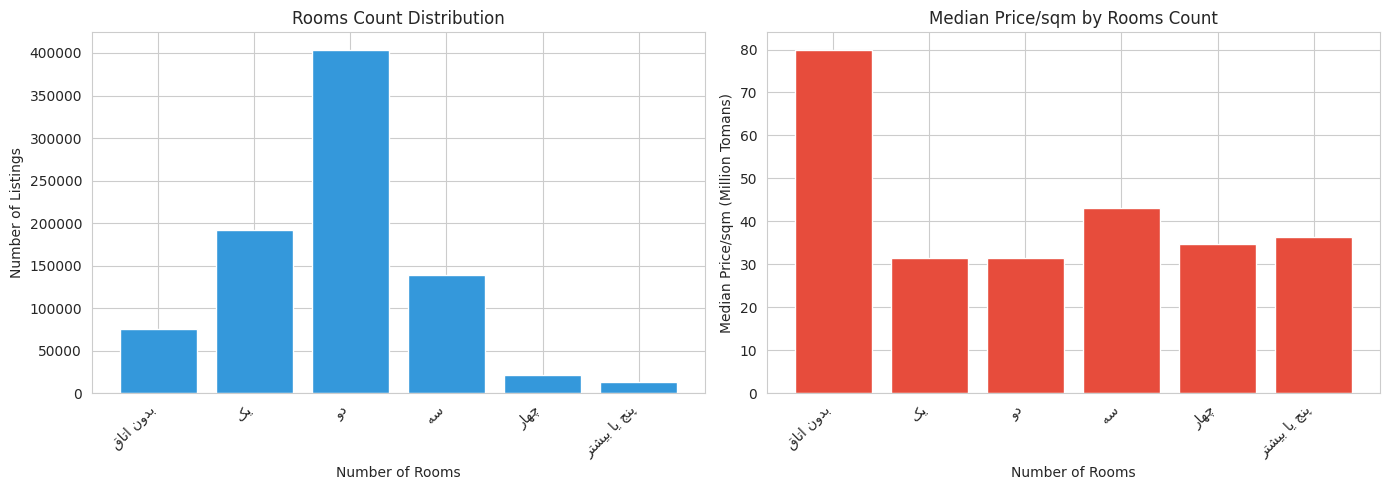

In [56]:
if 'rooms_count' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Define logical room order (0, 1, 2, 3, 4, 5+)
    room_order = ['بدون اتاق', 'یک', 'دو', 'سه', 'چهار', 'پنج یا بیشتر']
    
    # Room counts - reindex by logical order
    rooms_counts = df['rooms_count'].value_counts()
    rooms_counts = rooms_counts.reindex([r for r in room_order if r in rooms_counts.index])
    room_labels = [fix_persian(str(l)) for l in rooms_counts.index]
    axes[0].bar(range(len(rooms_counts)), rooms_counts.values, color=COLORS['secondary'], edgecolor='white')
    axes[0].set_xlabel('Number of Rooms')
    axes[0].set_ylabel('Number of Listings')
    axes[0].set_title('Rooms Count Distribution')
    axes[0].set_xticks(range(len(rooms_counts)))
    axes[0].set_xticklabels(room_labels, rotation=45, ha='right')
    
    # Rooms vs Price - also order by logical room order
    sell_rooms = df[(df['listing_type'] == 'sell') & df['rooms_count'].notna() & 
                    df['price_per_sqm'].notna() & (~df['price_sqm_outlier'])]
    if len(sell_rooms) > 0:
        rooms_price = sell_rooms.groupby('rooms_count')['price_per_sqm'].median().reset_index()
        # Reorder by logical room order
        rooms_price['room_order'] = rooms_price['rooms_count'].map({r: i for i, r in enumerate(room_order)})
        rooms_price = rooms_price.dropna(subset=['room_order']).sort_values('room_order')
        room_labels_p = [fix_persian(str(r)) for r in rooms_price['rooms_count']]
        axes[1].bar(range(len(rooms_price)), rooms_price['price_per_sqm'] / 1e6, 
                    color=COLORS['accent'], edgecolor='white')
        axes[1].set_xlabel('Number of Rooms')
        axes[1].set_ylabel('Median Price/sqm (Million Tomans)')
        axes[1].set_title('Median Price/sqm by Rooms Count')
        axes[1].set_xticks(range(len(rooms_price)))
        axes[1].set_xticklabels(room_labels_p, rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '02_rooms_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()


---

## 7. Univariate Analysis - Categorical Variables

### 7.1 City Distribution

In [57]:
print("=" * 60)
print("CITY DISTRIBUTION")
print("=" * 60)

city_counts = df['city_slug'].value_counts()
print(f"\nUnique cities: {len(city_counts)}")
print(f"\nTop 15 Cities:")
for i, (city, count) in enumerate(city_counts.head(15).items(), 1):
    print(f"{i:2d}. {city:20s}: {count:>10,} ({count/len(df)*100:.1f}%)")

print(f"\n→ Top 5 cities: {city_counts.head(5).sum()/len(df)*100:.1f}% of all listings")

CITY DISTRIBUTION

Unique cities: 421

Top 15 Cities:
 1. tehran              :    190,904 (19.1%)
 2. mashhad             :     69,032 (6.9%)
 3. karaj               :     49,367 (4.9%)
 4. shiraz              :     37,141 (3.7%)
 5. isfahan             :     36,953 (3.7%)
 6. tabriz              :     27,655 (2.8%)
 7. andisheh-new-town   :     20,847 (2.1%)
 8. ahvaz               :     19,590 (2.0%)
 9. qom                 :     17,109 (1.7%)
10. kermanshah          :     17,048 (1.7%)
11. rasht               :     16,833 (1.7%)
12. urmia               :     13,466 (1.3%)
13. bandar-abbas        :     11,555 (1.2%)
14. pardis-city         :     11,396 (1.1%)
15. kerman              :     11,319 (1.1%)

→ Top 5 cities: 38.3% of all listings


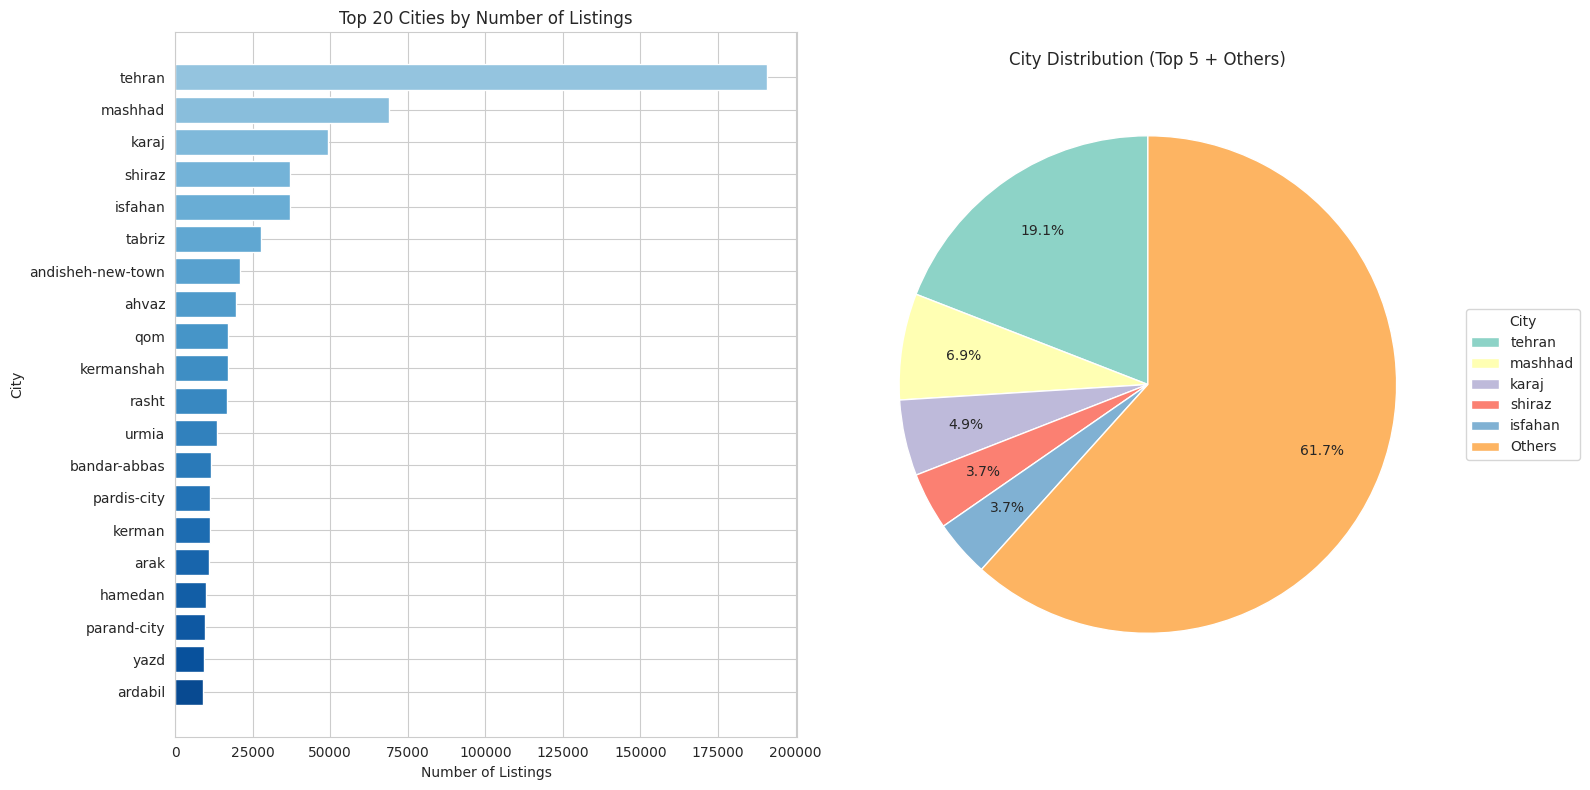

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart
top20 = city_counts.head(20)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top20)))[::-1]
axes[0].barh(top20.index[::-1], top20.values[::-1], color=colors)
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('City')
axes[0].set_title('Top 20 Cities by Number of Listings')

# Pie chart
top5 = city_counts.head(5)
others = pd.Series({'Others': city_counts[5:].sum()})
pie_data = pd.concat([top5, others])
colors_pie = plt.cm.Set3(range(len(pie_data)))
wedges, _, autotexts = axes[1].pie(pie_data.values, labels=None, autopct='%1.1f%%',
                                    startangle=90, colors=colors_pie, pctdistance=0.75)
axes[1].legend(wedges, pie_data.index, title='City', loc='center left', bbox_to_anchor=(1, 0.5))
axes[1].set_title('City Distribution (Top 5 + Others)')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_city_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Property Type Distribution

In [59]:
print("=" * 60)
print("PROPERTY TYPE DISTRIBUTION")
print("=" * 60)

cat3_counts = df['cat3_slug'].value_counts()
print(f"\nProperty types: {len(cat3_counts)}")
for i, (cat, count) in enumerate(cat3_counts.items(), 1):
    print(f"{i:2d}. {cat:30s}: {count:>10,} ({count/len(df)*100:.1f}%)")

PROPERTY TYPE DISTRIBUTION

Property types: 16
 1. apartment-sell                :    303,385 (30.3%)
 2. apartment-rent                :    211,880 (21.2%)
 3. plot-old                      :    133,570 (13.4%)
 4. house-villa-sell              :    121,753 (12.2%)
 5. house-villa-rent              :     64,678 (6.5%)
 6. shop-rent                     :     45,993 (4.6%)
 7. shop-sell                     :     21,855 (2.2%)
 8. office-rent                   :     21,418 (2.1%)
 9. suite-apartment               :     16,465 (1.6%)
10. presell                       :     15,781 (1.6%)
11. villa                         :     12,899 (1.3%)
12. industry-agriculture-business-sell:     11,851 (1.2%)
13. industry-agriculture-business-rent:      9,155 (0.9%)
14. office-sell                   :      5,155 (0.5%)
15. partnership                   :      3,622 (0.4%)
16. workspace                     :        539 (0.1%)


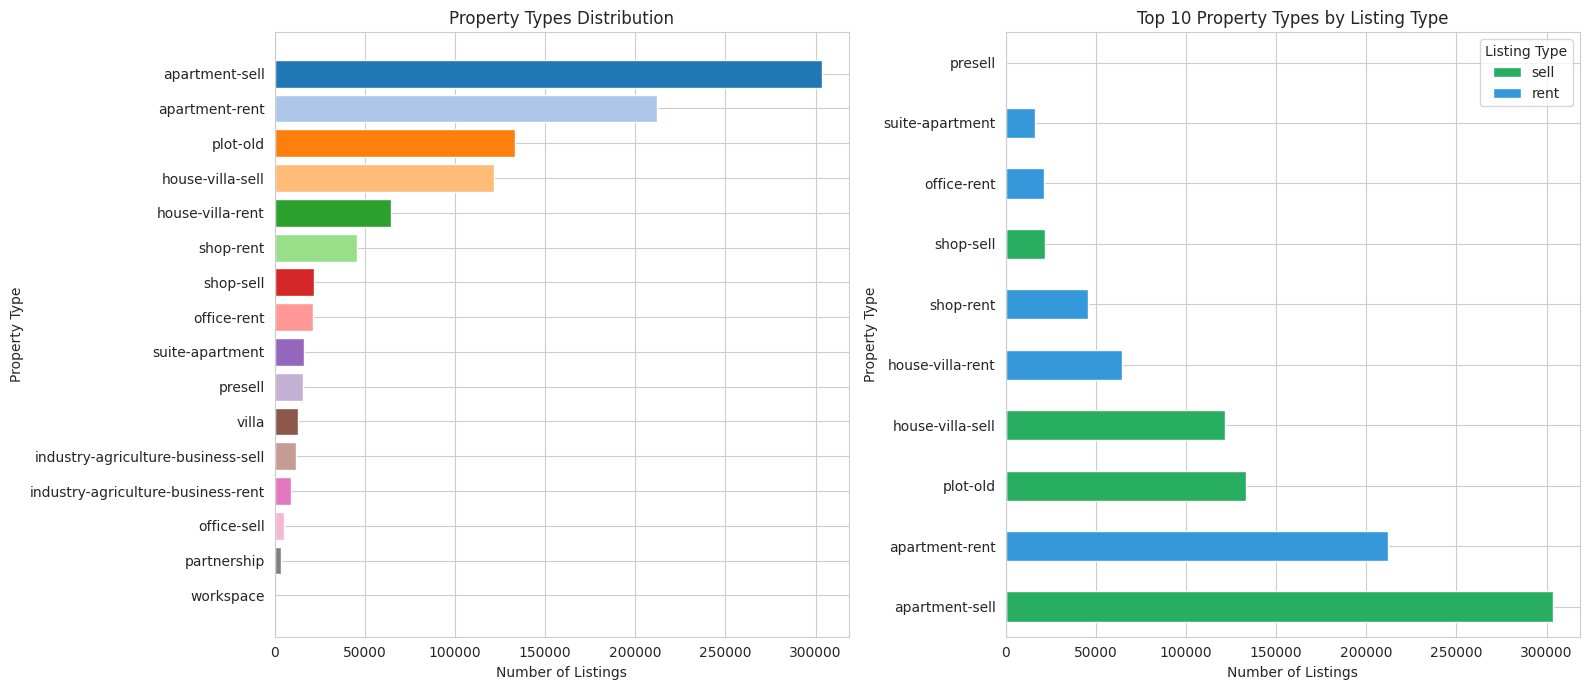

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# All types
colors = plt.cm.tab20(range(len(cat3_counts)))
axes[0].barh(cat3_counts.index[::-1], cat3_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('Property Type')
axes[0].set_title('Property Types Distribution')

# By sell/rent
cat3_by_type = df.groupby(['cat3_slug', 'listing_type']).size().unstack(fill_value=0)
top10 = cat3_counts.head(10).index.tolist()
cat3_top = cat3_by_type.loc[top10]
cols = [c for c in ['sell', 'rent'] if c in cat3_top.columns]
if cols:
    cat3_top[cols].plot(kind='barh', stacked=True, ax=axes[1], 
                        color=[COLORS['sell'], COLORS['rent']][:len(cols)])
    axes[1].set_xlabel('Number of Listings')
    axes[1].set_ylabel('Property Type')
    axes[1].set_title('Top 10 Property Types by Listing Type')
    axes[1].legend(title='Listing Type')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_property_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 User Type Distribution

In [61]:
print("=" * 60)
print("USER TYPE DISTRIBUTION")
print("=" * 60)

user_counts = df['user_type'].value_counts(dropna=False)
null_count = df['user_type'].isna().sum()

print(f"\nUser Type Breakdown:")
for user, count in user_counts.items():
    label = 'NULL/Unknown' if pd.isna(user) else user
    print(f"  {label:20s}: {count:>10,} ({count/len(df)*100:.1f}%)")

print(f"\n⚠ Missing: {null_count:,} ({null_count/len(df)*100:.1f}%) - Challenge for Phase 6")

USER TYPE DISTRIBUTION

User Type Breakdown:
  NULL/Unknown        :    711,118 (71.1%)
  مشاور املاک         :    256,006 (25.6%)
  شخصی                :     32,876 (3.3%)

⚠ Missing: 711,118 (71.1%) - Challenge for Phase 6


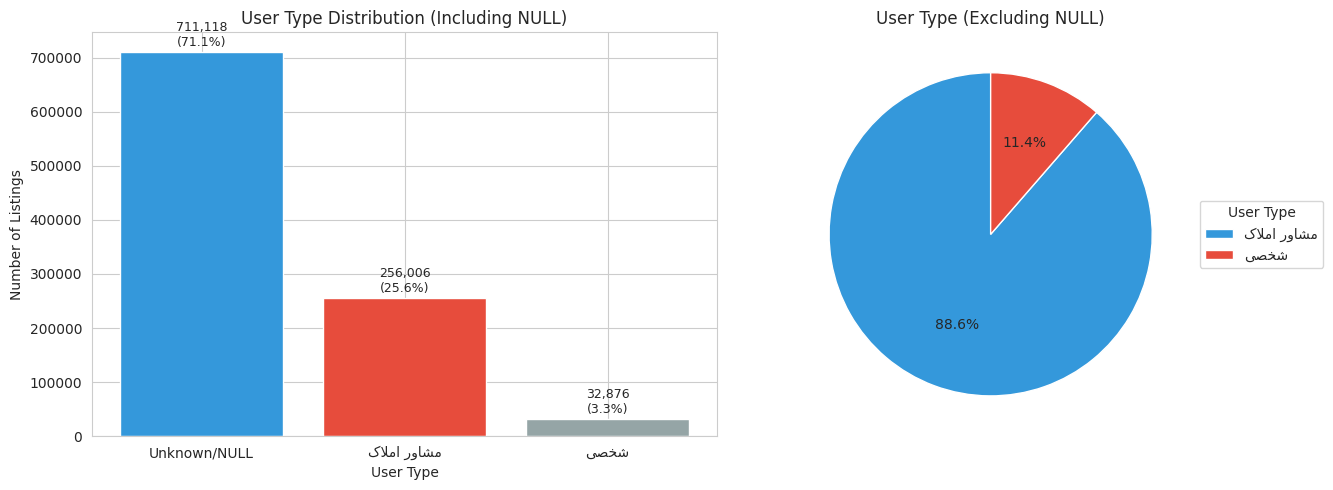

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar with NULL
user_labels = [fix_persian(str(u)) if pd.notna(u) else 'Unknown/NULL' for u in user_counts.index]
colors = [COLORS['secondary'], COLORS['accent'], COLORS['neutral']][:len(user_counts)]
bars = axes[0].bar(range(len(user_counts)), user_counts.values, color=colors)
axes[0].set_xlabel('User Type')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('User Type Distribution (Including NULL)')
axes[0].set_xticks(range(len(user_counts)))
axes[0].set_xticklabels(user_labels)
for bar, val in zip(bars, user_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# Pie (excluding NULL)
user_valid = df['user_type'].value_counts(dropna=True)
if len(user_valid) > 0:
    labels_valid = [fix_persian(str(u)) for u in user_valid.index]
    wedges, _, _ = axes[1].pie(user_valid.values, labels=None, autopct='%1.1f%%',
                               colors=[COLORS['secondary'], COLORS['accent']][:len(user_valid)], 
                               startangle=90, pctdistance=0.6)
    axes[1].legend(wedges, labels_valid, title='User Type', loc='center left', bbox_to_anchor=(1, 0.5))
    axes[1].set_title('User Type (Excluding NULL)')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_user_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Bivariate Analysis - Correlations

### 8.1 Correlation Matrix

**Important**: We use the FILTERED dataset (df_sell_clean) to avoid outliers distorting correlations.

In [63]:
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Use FILTERED data for meaningful correlations
corr_cols = ['price_value', 'building_size', 'price_per_sqm']
df_corr = df_sell_clean[corr_cols].dropna()

print(f"\nRecords for correlation: {len(df_corr):,}")

corr_matrix = df_corr.corr()

print(f"\nCorrelations with Price Value:")
print("-" * 40)
price_corr = corr_matrix['price_value'].drop('price_value').sort_values(ascending=False)
for col, val in price_corr.items():
    strength = 'Strong' if abs(val) > 0.5 else 'Moderate' if abs(val) > 0.3 else 'Weak'
    print(f"  {col:20s}: {val:>7.3f} ({strength})")

print(f"\n📊 Key Finding: Building size shows {abs(price_corr['building_size']):.1%} correlation with price")

CORRELATION ANALYSIS

Records for correlation: 477,340

Correlations with Price Value:
----------------------------------------
  building_size       :   0.896 (Strong)
  price_per_sqm       :   0.042 (Weak)

📊 Key Finding: Building size shows 89.6% correlation with price


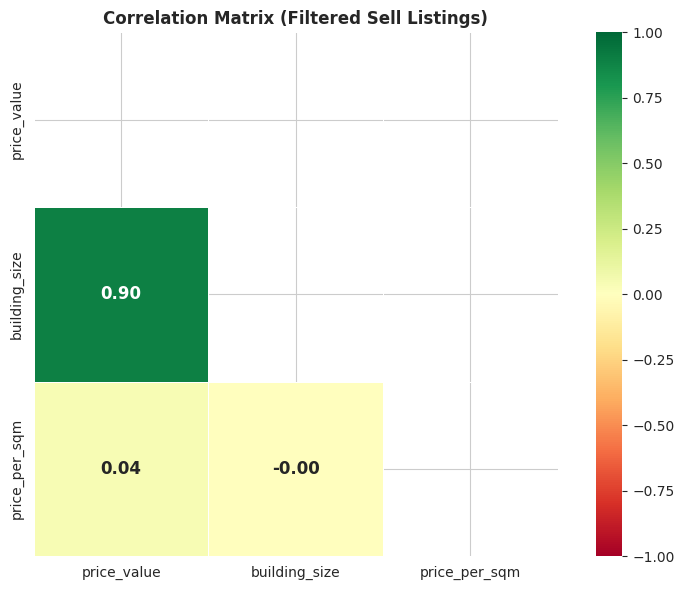


✓ Using filtered data shows meaningful correlations
  Building size is a key predictor for Phase 5


In [64]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Correlation Matrix (Filtered Sell Listings)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Using filtered data shows meaningful correlations")
print("  Building size is a key predictor for Phase 5")

### 8.2 Key Scatter Plots

Scatter plots reveal the nature of relationships between variables.

Scatter sample: 30,000 records


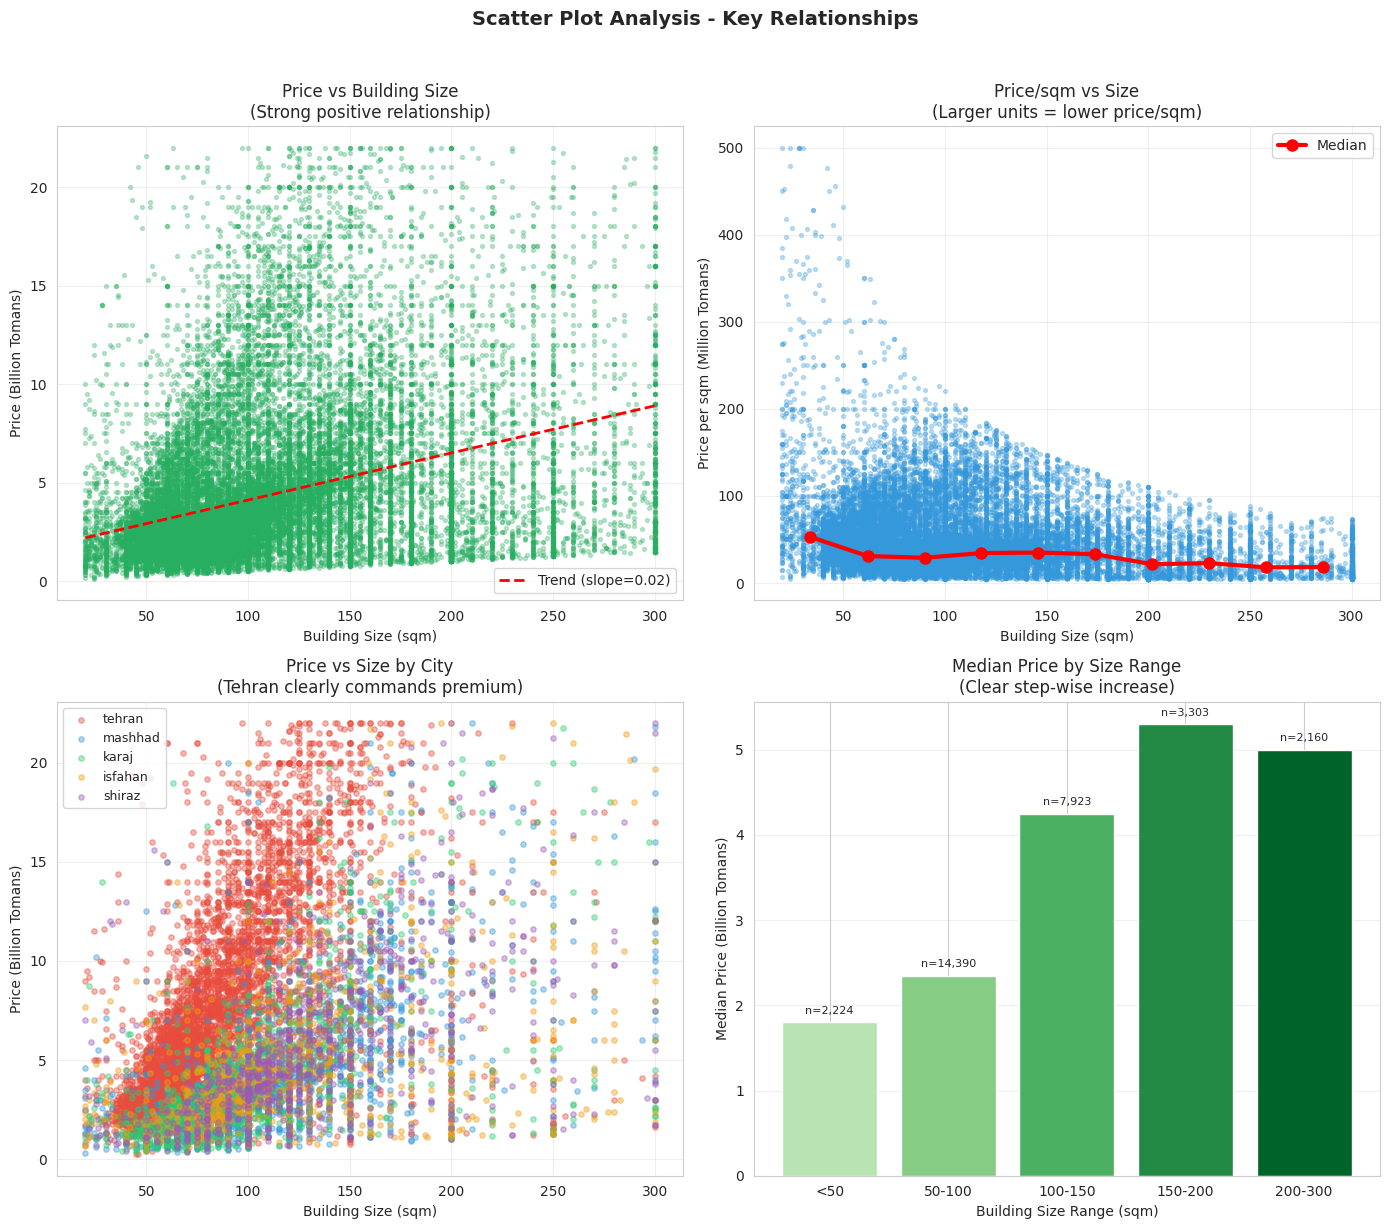


📊 Key Insights:
  • Strong positive correlation: larger size → higher price
  • Economy of scale: larger units have lower price/sqm
  • Location matters: Tehran commands significant premium


In [65]:
# Key Scatter Plots - with clear insights
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Filter for visualization
scatter_data = df_sell_clean[
    (df_sell_clean['building_size'] >= 20) & 
    (df_sell_clean['building_size'] <= 300) &
    (df_sell_clean['price_value'] <= df_sell_clean['price_value'].quantile(0.95))
].sample(n=min(30000, len(df_sell_clean)), random_state=42)

print(f"Scatter sample: {len(scatter_data):,} records")

# 1. Price vs Size with trend
axes[0, 0].scatter(scatter_data['building_size'], scatter_data['price_value'] / 1e9,
                   alpha=0.3, s=8, c=COLORS['sell'])
z = np.polyfit(scatter_data['building_size'], scatter_data['price_value'] / 1e9, 1)
p = np.poly1d(z)
x_line = np.linspace(20, 300, 100)
axes[0, 0].plot(x_line, p(x_line), 'r--', lw=2, label=f'Trend (slope={z[0]:.2f})')
axes[0, 0].set_xlabel('Building Size (sqm)')
axes[0, 0].set_ylabel('Price (Billion Tomans)')
axes[0, 0].set_title('Price vs Building Size\n(Strong positive relationship)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Price/sqm vs Size (economy of scale)
axes[0, 1].scatter(scatter_data['building_size'], scatter_data['price_per_sqm'] / 1e6,
                   alpha=0.3, s=8, c=COLORS['secondary'])
# Median by bins
bins = pd.cut(scatter_data['building_size'], bins=10)
medians = scatter_data.groupby(bins)['price_per_sqm'].median() / 1e6
centers = [(b.left + b.right) / 2 for b in medians.index]
axes[0, 1].plot(centers, medians.values, 'r-', lw=3, marker='o', markersize=8, label='Median')
axes[0, 1].set_xlabel('Building Size (sqm)')
axes[0, 1].set_ylabel('Price per sqm (Million Tomans)')
axes[0, 1].set_title('Price/sqm vs Size\n(Larger units = lower price/sqm)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Price by top 5 cities
top5_cities = df_sell_clean['city_slug'].value_counts().head(5).index.tolist()
city_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for city, color in zip(top5_cities, city_colors):
    city_data = scatter_data[scatter_data['city_slug'] == city]
    if len(city_data) > 0:
        axes[1, 0].scatter(city_data['building_size'], city_data['price_value'] / 1e9,
                          alpha=0.4, s=15, c=color, label=city)
axes[1, 0].set_xlabel('Building Size (sqm)')
axes[1, 0].set_ylabel('Price (Billion Tomans)')
axes[1, 0].set_title('Price vs Size by City\n(Tehran clearly commands premium)')
axes[1, 0].legend(loc='upper left', fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# 4. Median price by size bins (bar chart - clearer insight)
scatter_data['size_bin'] = pd.cut(scatter_data['building_size'], 
                                  bins=[0, 50, 100, 150, 200, 300],
                                  labels=['<50', '50-100', '100-150', '150-200', '200-300'])
size_stats = scatter_data.groupby('size_bin')['price_value'].agg(['median', 'count']).reset_index()
bars = axes[1, 1].bar(range(len(size_stats)), size_stats['median'] / 1e9, 
                       color=plt.cm.Greens(np.linspace(0.3, 0.9, len(size_stats))))
axes[1, 1].set_xlabel('Building Size Range (sqm)')
axes[1, 1].set_ylabel('Median Price (Billion Tomans)')
axes[1, 1].set_title('Median Price by Size Range\n(Clear step-wise increase)')
axes[1, 1].set_xticks(range(len(size_stats)))
axes[1, 1].set_xticklabels(size_stats['size_bin'])
for i, (bar, n) in enumerate(zip(bars, size_stats['count'])):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'n={n:,}', ha='center', fontsize=8)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Scatter Plot Analysis - Key Relationships', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key Insights:")
print("  • Strong positive correlation: larger size → higher price")
print("  • Economy of scale: larger units have lower price/sqm")
print("  • Location matters: Tehran commands significant premium")

---

## 9. Price Analysis by Segments

### 9.1 Price by City

In [66]:
print("=" * 60)
print("PRICE BY CITY")
print("=" * 60)

city_price = df_sell_clean.groupby('city_slug').agg({
    'price_per_sqm': ['median', 'mean', 'count']
}).round(0)
city_price.columns = ['median_psqm', 'mean_psqm', 'count']
city_price = city_price.reset_index()
city_price_filtered = city_price[city_price['count'] >= 100].sort_values('median_psqm', ascending=False)

print(f"\nTop 15 Cities by Median Price/sqm (min 100 listings):")
for i, (_, row) in enumerate(city_price_filtered.head(15).iterrows(), 1):
    print(f"{i:2d}. {row['city_slug']:20s}: {row['median_psqm']/1e6:>8.1f}M  (n={int(row['count']):,})")

PRICE BY CITY

Top 15 Cities by Median Price/sqm (min 100 listings):
 1. kish                :    102.5M  (n=1,842)
 2. tehran              :     87.2M  (n=94,141)
 3. lavasan-city        :     70.0M  (n=388)
 4. fasham-city         :     64.3M  (n=214)
 5. salman-shahr        :     50.0M  (n=666)
 6. garmdareh           :     43.6M  (n=796)
 7. shiraz              :     41.0M  (n=15,743)
 8. lahijan             :     40.0M  (n=2,072)
 9. arak                :     39.4M  (n=4,539)
10. qazvin              :     39.2M  (n=3,334)
11. hamedan             :     38.5M  (n=4,043)
12. isfahan             :     38.2M  (n=18,041)
13. bandar-abbas        :     37.3M  (n=4,918)
14. shahriar-city       :     35.8M  (n=3,021)
15. karaj               :     35.0M  (n=26,691)


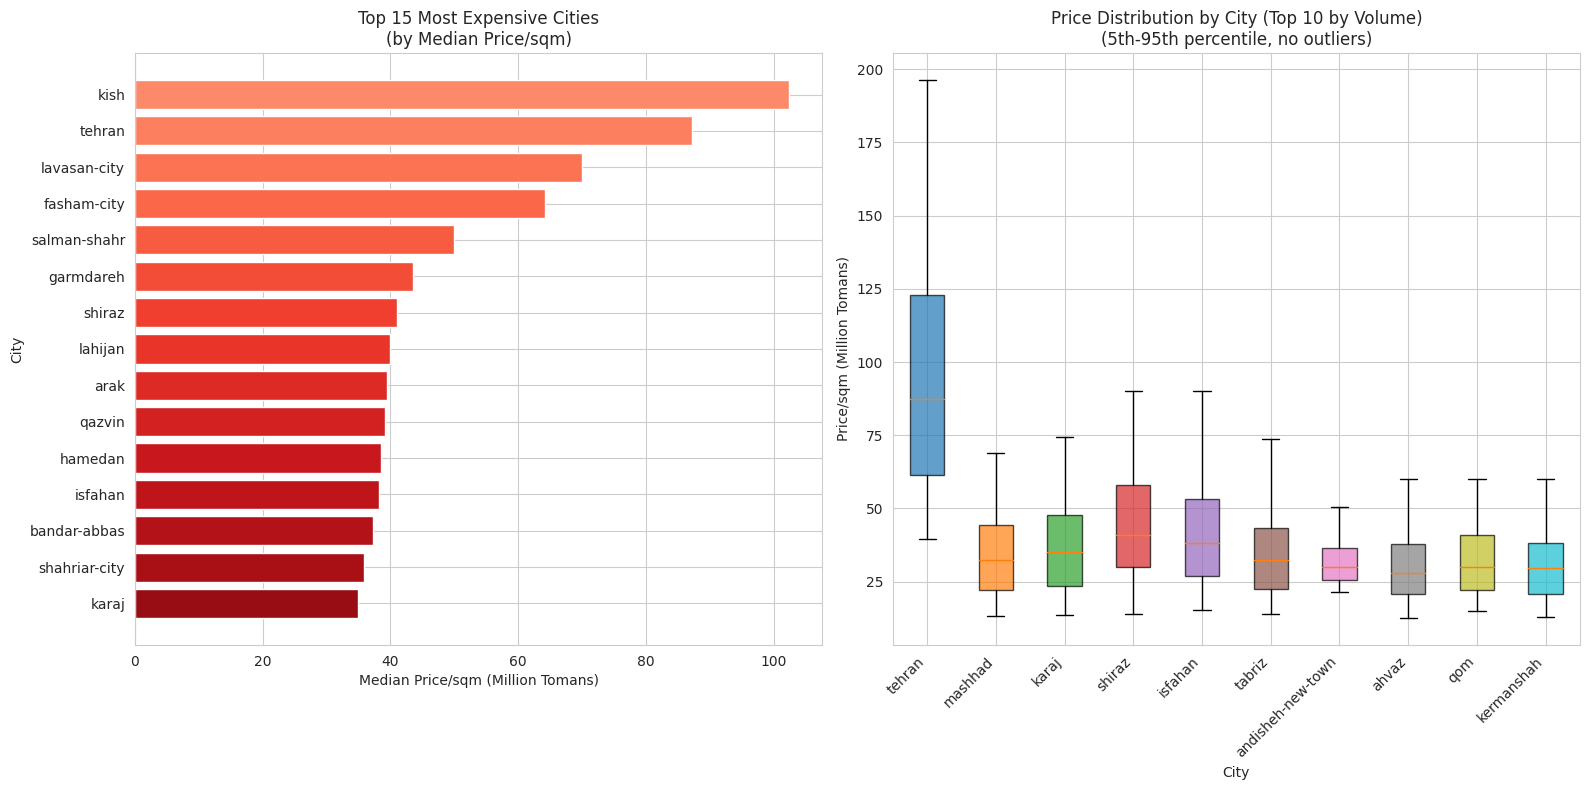

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15 by price
top15 = city_price_filtered.head(15)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top15)))[::-1]
axes[0].barh(top15['city_slug'][::-1], top15['median_psqm'][::-1] / 1e6, color=colors)
axes[0].set_xlabel('Median Price/sqm (Million Tomans)')
axes[0].set_ylabel('City')
axes[0].set_title('Top 15 Most Expensive Cities\n(by Median Price/sqm)')

# Box plot top 10 by volume (with whiskers at 5th/95th percentile)
top10_vol = df['city_slug'].value_counts().head(10).index.tolist()
box_data = []
for city in top10_vol:
    d = df_sell_clean[df_sell_clean['city_slug'] == city]['price_per_sqm'] / 1e6
    # Clip to 5th-95th percentile for readability
    d = d[(d >= d.quantile(0.05)) & (d <= d.quantile(0.95))]
    if len(d) > 0:
        box_data.append(d)

bp = axes[1].boxplot(box_data, labels=top10_vol, patch_artist=True, vert=True,
                     whis=[5, 95], showfliers=False)  # Hide outliers for clarity
colors_box = plt.cm.tab10(range(len(top10_vol)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('City')
axes[1].set_ylabel('Price/sqm (Million Tomans)')
axes[1].set_title('Price Distribution by City (Top 10 by Volume)\n(5th-95th percentile, no outliers)')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_price_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Price by Property Type

In [68]:
print("=" * 60)
print("PRICE BY PROPERTY TYPE")
print("=" * 60)

cat3_price = df_sell_clean.groupby('cat3_slug').agg({
    'price_per_sqm': ['median', 'mean', 'count']
}).round(0)
cat3_price.columns = ['median_psqm', 'mean_psqm', 'count']
cat3_price = cat3_price.reset_index()
cat3_price = cat3_price[cat3_price['count'] >= 50].sort_values('median_psqm', ascending=False)

print(f"\nProperty Types by Median Price/sqm:")
for _, row in cat3_price.iterrows():
    print(f"  {row['cat3_slug']:30s}: {row['median_psqm']/1e6:>8.1f}M  (n={int(row['count']):,})")

PRICE BY PROPERTY TYPE

Property Types by Median Price/sqm:
  shop-sell                     :    100.0M  (n=15,538)
  office-sell                   :     90.0M  (n=4,183)
  apartment-sell                :     36.7M  (n=293,355)
  house-villa-sell              :     23.5M  (n=108,929)
  industry-agriculture-business-sell:     15.1M  (n=3,008)
  plot-old                      :     13.0M  (n=52,327)


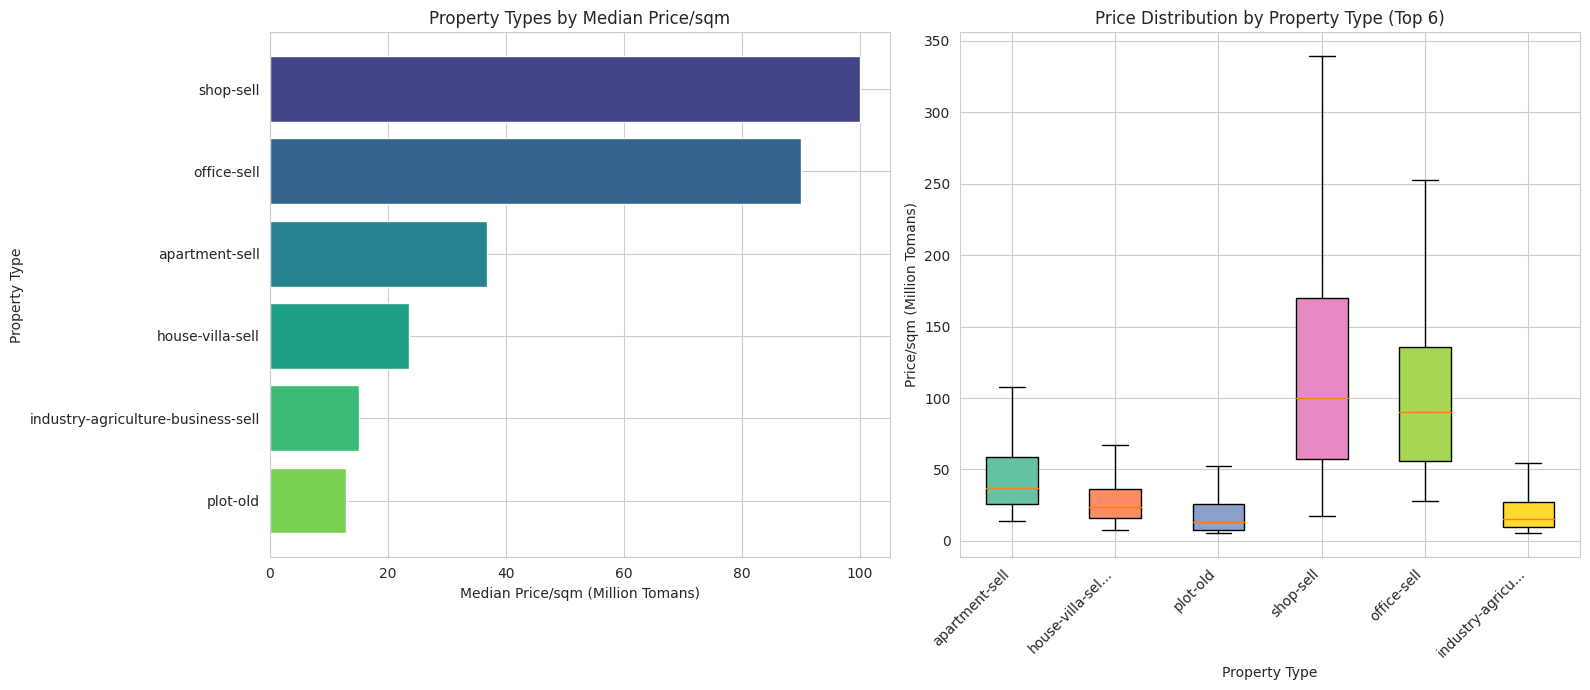

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(cat3_price)))
axes[0].barh(cat3_price['cat3_slug'][::-1], cat3_price['median_psqm'][::-1] / 1e6, color=colors[::-1])
axes[0].set_xlabel('Median Price/sqm (Million Tomans)')
axes[0].set_ylabel('Property Type')
axes[0].set_title('Property Types by Median Price/sqm')

# Box plot top 6
top6 = df_sell_clean['cat3_slug'].value_counts().head(6).index.tolist()
box_data = []
labels = []
for cat in top6:
    d = df_sell_clean[df_sell_clean['cat3_slug'] == cat]['price_per_sqm'] / 1e6
    d = d[(d >= d.quantile(0.05)) & (d <= d.quantile(0.95))]
    if len(d) > 0:
        box_data.append(d)
        labels.append(cat[:15] + '...' if len(cat) > 15 else cat)

bp = axes[1].boxplot(box_data, labels=labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], plt.cm.Set2(range(len(box_data)))):
    patch.set_facecolor(color)
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Price/sqm (Million Tomans)')
axes[1].set_title('Price Distribution by Property Type (Top 6)')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_price_by_property_type.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Price by User Type

In [70]:
print("=" * 60)
print("PRICE BY USER TYPE")
print("=" * 60)

user_data = df_sell_clean[df_sell_clean['user_type'].notna()]

if len(user_data) > 0:
    user_price = user_data.groupby('user_type').agg({
        'price_per_sqm': ['median', 'mean', 'count'],
        'price_value': ['median']
    })
    user_price.columns = ['median_psqm', 'mean_psqm', 'count', 'median_price']
    
    for ut, row in user_price.iterrows():
        print(f"\n{ut}:")
        print(f"  Listings: {int(row['count']):,}")
        print(f"  Median Price/sqm: {row['median_psqm']/1e6:.1f}M Tomans")
        print(f"  Median Total: {row['median_price']/1e9:.2f}B Tomans")

PRICE BY USER TYPE

شخصی:
  Listings: 13,271
  Median Price/sqm: 27.0M Tomans
  Median Total: 2.90B Tomans

مشاور املاک:
  Listings: 143,291
  Median Price/sqm: 38.1M Tomans
  Median Total: 4.00B Tomans


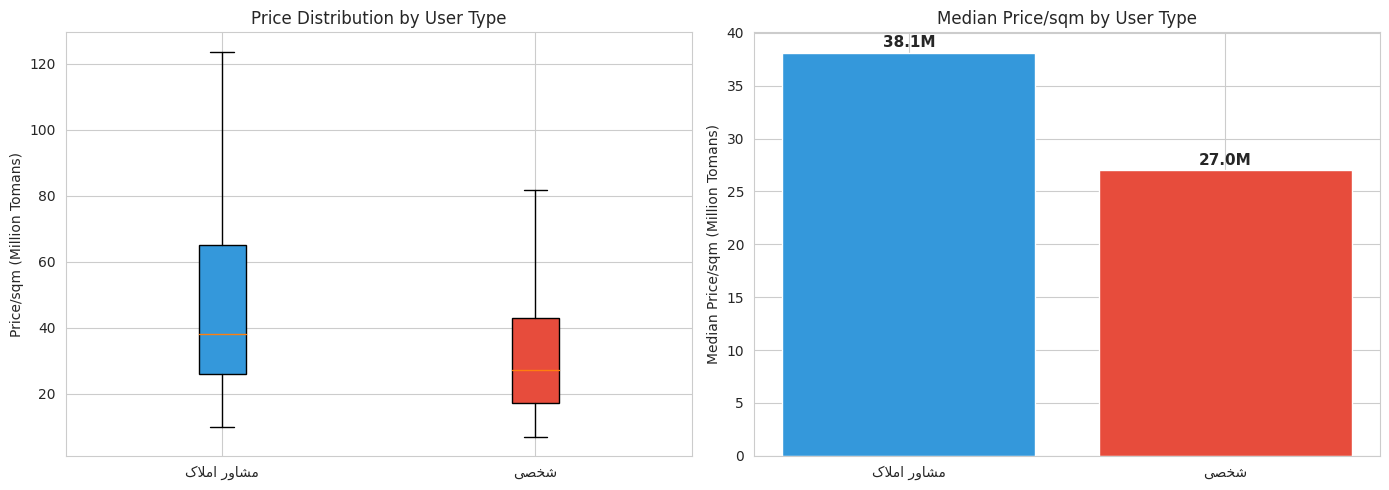

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(user_data) > 0:
    user_types = user_data['user_type'].unique()
    
    # Box plot (clipped)
    box_data = []
    labels = []
    for ut in user_types:
        d = user_data[user_data['user_type'] == ut]['price_per_sqm'] / 1e6
        d = d[(d >= d.quantile(0.05)) & (d <= d.quantile(0.95))]
        if len(d) > 0:
            box_data.append(d)
            labels.append(fix_persian(str(ut)))
    
    bp = axes[0].boxplot(box_data, labels=labels, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], [COLORS['secondary'], COLORS['accent']]):
        patch.set_facecolor(color)
    axes[0].set_ylabel('Price/sqm (Million Tomans)')
    axes[0].set_title('Price Distribution by User Type')
    
    # Bar chart of medians
    medians = [user_data[user_data['user_type'] == ut]['price_per_sqm'].median() / 1e6 for ut in user_types]
    bars = axes[1].bar(range(len(user_types)), medians, 
                       color=[COLORS['secondary'], COLORS['accent']][:len(user_types)])
    axes[1].set_xticks(range(len(user_types)))
    axes[1].set_xticklabels([fix_persian(str(ut)) for ut in user_types])
    axes[1].set_ylabel('Median Price/sqm (Million Tomans)')
    axes[1].set_title('Median Price/sqm by User Type')
    for bar, val in zip(bars, medians):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                     f'{val:.1f}M', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_price_by_user_type.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 10. Temporal Analysis

In [72]:
print("=" * 60)
print("TEMPORAL ANALYSIS")
print("=" * 60)

if 'year_month' in df.columns and df['year_month'].notna().sum() > 0:
    monthly = df.groupby('year_month').size()
    print(f"\nTime range: {monthly.index.min()} to {monthly.index.max()}")
    print(f"Months covered: {len(monthly)}")
    
    if len(df_sell_clean) > 0:
        sell_monthly = df_sell_clean.groupby('year_month')['price_per_sqm'].median()
        if len(sell_monthly) > 1:
            change = (sell_monthly.iloc[-1] / sell_monthly.iloc[0] - 1) * 100
            print(f"\nPrice/sqm change: {change:+.1f}%")

TEMPORAL ANALYSIS

Time range: 2020-02 to 2025-03
Months covered: 46

Price/sqm change: -79.6%


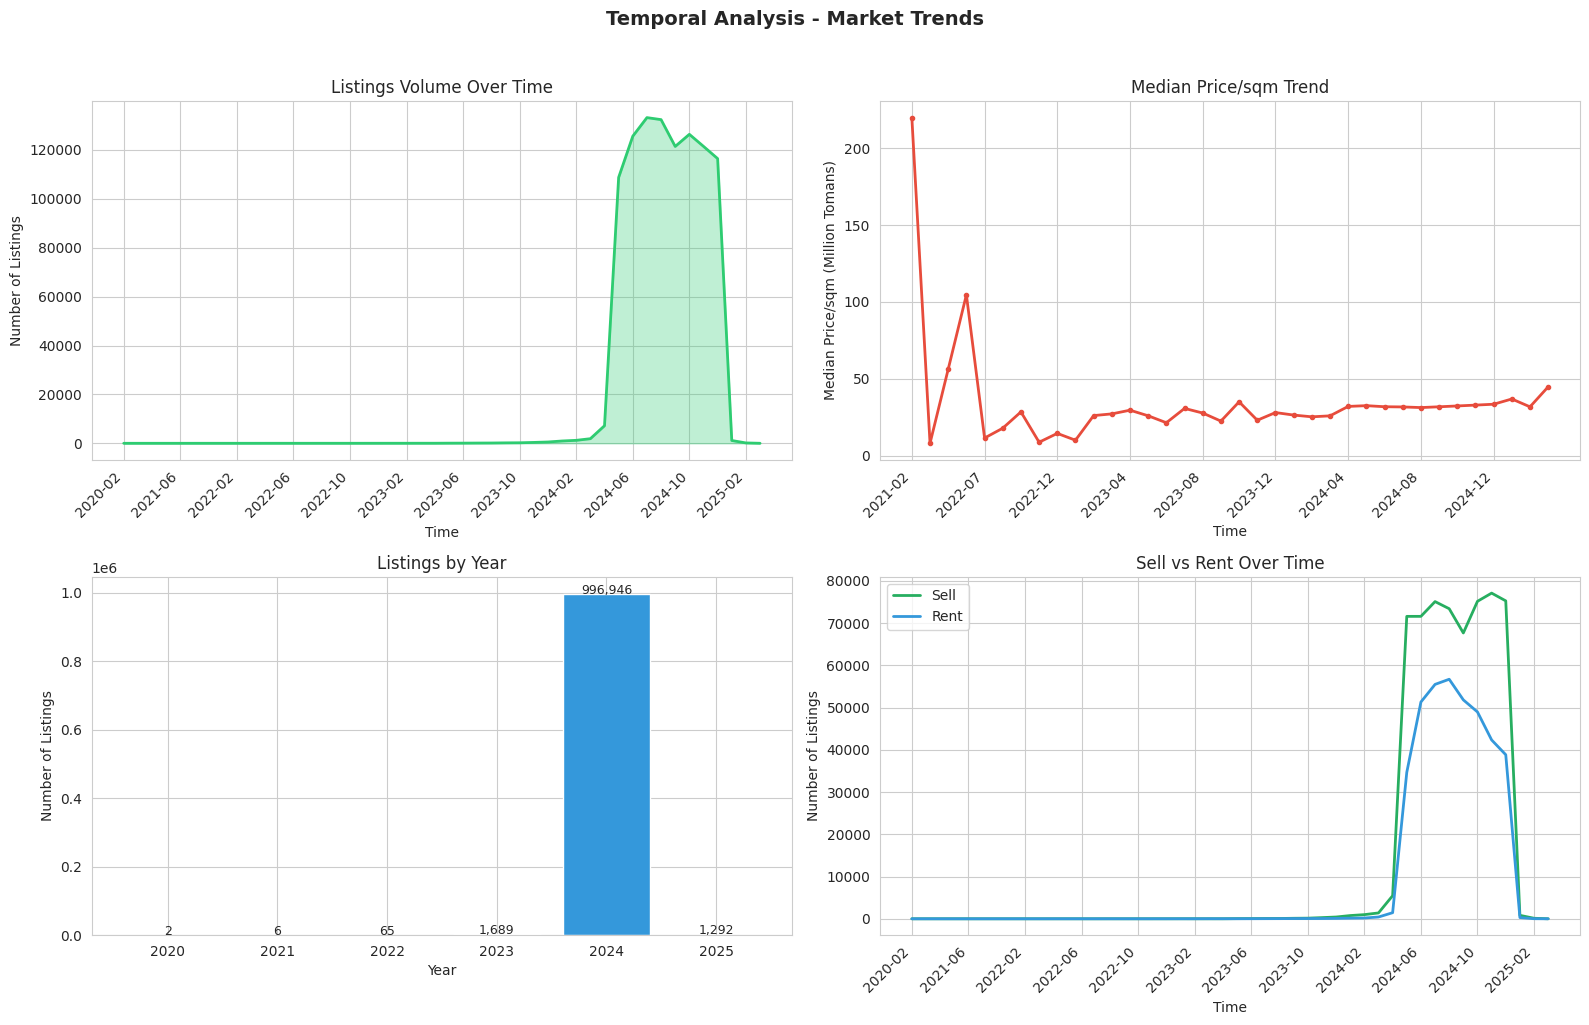

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if 'year_month' in df.columns and df['year_month'].notna().sum() > 0:
    monthly = df.groupby('year_month').size()
    x_dates = [str(p) for p in monthly.index]
    step = max(1, len(x_dates) // 10)
    
    # 1. Volume over time
    axes[0, 0].plot(range(len(monthly)), monthly.values, color=COLORS['primary'], lw=2)
    axes[0, 0].fill_between(range(len(monthly)), monthly.values, alpha=0.3, color=COLORS['primary'])
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('Number of Listings')
    axes[0, 0].set_title('Listings Volume Over Time')
    axes[0, 0].set_xticks(range(0, len(x_dates), step))
    axes[0, 0].set_xticklabels([x_dates[i] for i in range(0, len(x_dates), step)], rotation=45, ha='right')
    
    # 2. Price trend
    if len(df_sell_clean) > 0:
        sell_monthly = df_sell_clean.groupby('year_month')['price_per_sqm'].median()
        axes[0, 1].plot(range(len(sell_monthly)), sell_monthly.values / 1e6, 
                        color=COLORS['accent'], lw=2, marker='o', markersize=3)
        axes[0, 1].set_xlabel('Time')
        axes[0, 1].set_ylabel('Median Price/sqm (Million Tomans)')
        axes[0, 1].set_title('Median Price/sqm Trend')
        axes[0, 1].set_xticks(range(0, len(sell_monthly), step))
        axes[0, 1].set_xticklabels([str(sell_monthly.index[i]) for i in range(0, len(sell_monthly), step)], 
                                   rotation=45, ha='right')
    
    # 3. By year
    if 'year' in df.columns:
        yearly = df.groupby('year').size()
        bars = axes[1, 0].bar([str(int(y)) for y in yearly.index], yearly.values, 
                              color=COLORS['secondary'], edgecolor='white')
        axes[1, 0].set_xlabel('Year')
        axes[1, 0].set_ylabel('Number of Listings')
        axes[1, 0].set_title('Listings by Year')
        for bar, val in zip(bars, yearly.values):
            axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                            f'{val:,}', ha='center', fontsize=9)
    
    # 4. Sell vs Rent
    type_monthly = df.groupby(['year_month', 'listing_type']).size().unstack(fill_value=0)
    for lt, color in [('sell', COLORS['sell']), ('rent', COLORS['rent'])]:
        if lt in type_monthly.columns:
            axes[1, 1].plot(range(len(type_monthly)), type_monthly[lt].values, 
                           label=lt.capitalize(), color=color, lw=2)
    axes[1, 1].set_xlabel('Time')
    axes[1, 1].set_ylabel('Number of Listings')
    axes[1, 1].set_title('Sell vs Rent Over Time')
    axes[1, 1].legend()
    axes[1, 1].set_xticks(range(0, len(type_monthly), step))
    axes[1, 1].set_xticklabels([str(type_monthly.index[i]) for i in range(0, len(type_monthly), step)], 
                               rotation=45, ha='right')

plt.suptitle('Temporal Analysis - Market Trends', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 11. Rental Market Overview

In [74]:
print("=" * 60)
print("RENTAL MARKET")
print("=" * 60)

print(f"\nTotal rentals: {len(df_rent):,}")

if 'credit_value' in df_rent.columns:
    credit = df_rent['credit_value'].dropna()
    credit = credit[credit > 0]
    print(f"\nCredit (Rahn): {len(credit):,} records")
    print(f"  Median: {credit.median()/1e9:.2f}B Tomans")

if 'rent_value' in df_rent.columns:
    rent = df_rent['rent_value'].dropna()
    rent = rent[rent > 0]
    print(f"\nMonthly Rent: {len(rent):,} records")
    print(f"  Median: {rent.median()/1e6:.1f}M Tomans")

RENTAL MARKET

Total rentals: 383,028

Credit (Rahn): 349,223 records
  Median: 0.25B Tomans

Monthly Rent: 292,074 records
  Median: 6.2M Tomans


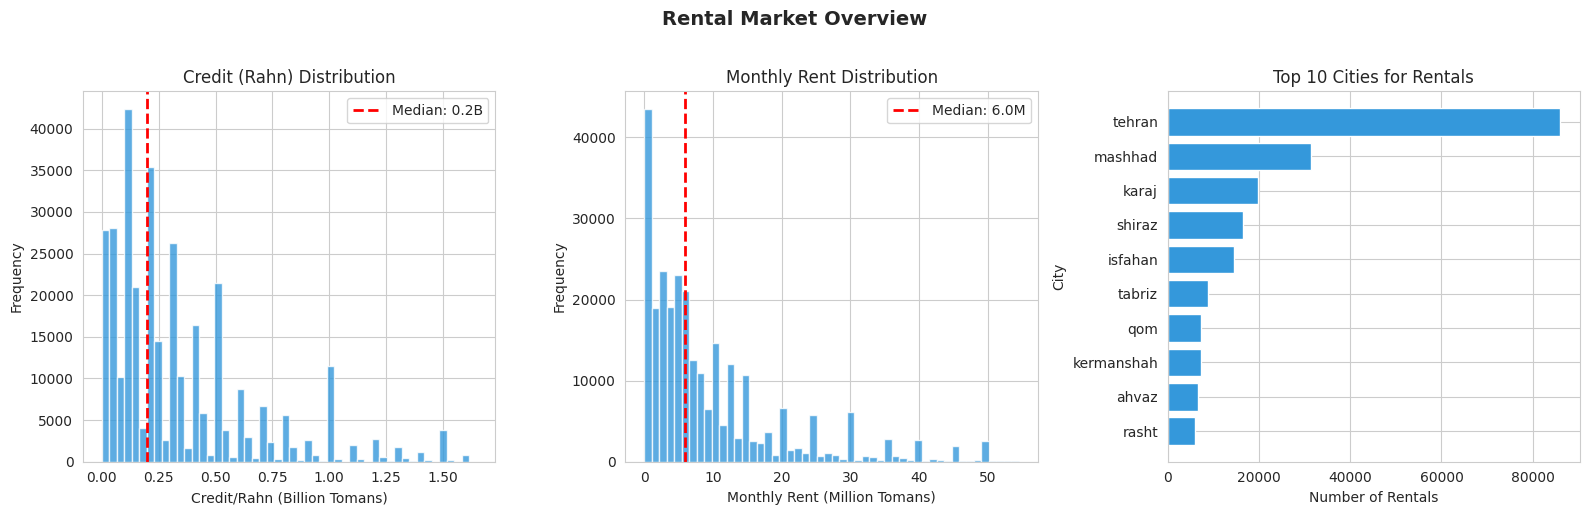

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Credit
if 'credit_value' in df_rent.columns:
    credit = df_rent['credit_value'].dropna()
    credit = credit[(credit > 0) & (credit < credit.quantile(0.95))]
    if len(credit) > 0:
        axes[0].hist(credit / 1e9, bins=50, color=COLORS['rent'], edgecolor='white', alpha=0.8)
        axes[0].axvline(x=credit.median()/1e9, color='red', linestyle='--', lw=2,
                        label=f'Median: {credit.median()/1e9:.1f}B')
        axes[0].set_xlabel('Credit/Rahn (Billion Tomans)')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Credit (Rahn) Distribution')
        axes[0].legend()

# Rent
if 'rent_value' in df_rent.columns:
    rent = df_rent['rent_value'].dropna()
    rent = rent[(rent > 0) & (rent < rent.quantile(0.95))]
    if len(rent) > 0:
        axes[1].hist(rent / 1e6, bins=50, color=COLORS['secondary'], edgecolor='white', alpha=0.8)
        axes[1].axvline(x=rent.median()/1e6, color='red', linestyle='--', lw=2,
                        label=f'Median: {rent.median()/1e6:.1f}M')
        axes[1].set_xlabel('Monthly Rent (Million Tomans)')
        axes[1].set_ylabel('Frequency')
        axes[1].set_title('Monthly Rent Distribution')
        axes[1].legend()

# By city
rent_city = df_rent['city_slug'].value_counts().head(10)
axes[2].barh(rent_city.index[::-1], rent_city.values[::-1], color=COLORS['rent'], edgecolor='white')
axes[2].set_xlabel('Number of Rentals')
axes[2].set_ylabel('City')
axes[2].set_title('Top 10 Cities for Rentals')

plt.suptitle('Rental Market Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_rental_market.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 12. Statistical Summary

In [76]:
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

summary = pd.DataFrame({
    'Metric': [
        'Total Sell Listings', 'Clean Sell Listings', 'Median Price (B)',
        'Median Price/sqm (M)', 'Median Size (sqm)', 'Unique Cities', 'Property Types'
    ],
    'Value': [
        f"{len(df[df['listing_type'] == 'sell']):,}",
        f"{len(df_sell_clean):,}",
        f"{df_sell_clean['price_value'].median()/1e9:.2f}",
        f"{df_sell_clean['price_per_sqm'].median()/1e6:.1f}",
        f"{df_sell_clean['building_size'].median():.0f}",
        f"{df_sell_clean['city_slug'].nunique()}",
        f"{df_sell_clean['cat3_slug'].nunique()}"
    ]
})
print(summary.to_string(index=False))

summary.to_csv(DATA_PROCESSED / 'eda_sell_summary.csv', index=False)
print(f"\n✓ Saved: eda_sell_summary.csv")

STATISTICAL SUMMARY
              Metric   Value
 Total Sell Listings 597,569
 Clean Sell Listings 477,340
    Median Price (B)    3.30
Median Price/sqm (M)    32.1
   Median Size (sqm)     100
       Unique Cities     417
      Property Types       6

✓ Saved: eda_sell_summary.csv


In [77]:
# City statistics
city_stats = df_sell_clean.groupby('city_slug').agg({
    'price_per_sqm': ['median', 'mean', 'count'],
    'building_size': ['median'],
    'price_value': ['median']
}).round(0)
city_stats.columns = ['_'.join(c) for c in city_stats.columns]
city_stats = city_stats.reset_index().sort_values('price_per_sqm_count', ascending=False)
city_stats.to_csv(DATA_PROCESSED / 'eda_city_statistics.csv', index=False)
print(f"✓ Saved: eda_city_statistics.csv")
city_stats.head(10)

✓ Saved: eda_city_statistics.csv


,city_slug,price_per_sqm_median,price_per_sqm_mean,price_per_sqm_count,building_size_median,price_value_median
393,tehran,87162162.00,104650101.00,94141,85.00,7100000000.00
250,mashhad,32294118.00,39770588.00,32187,105.00,3350000000.00
181,karaj,35000000.00,42217565.00,26691,96.00,3300000000.00
164,isfahan,38235294.00,49430341.00,18041,120.00,4390000000.00
366,shiraz,41025641.00,51474076.00,15743,130.00,5300000000.00
26,andisheh-new-town,30000000.00,35123145.00,15563,60.00,1700000000.00
384,tabriz,32555556.00,43917711.00,14529,100.00,3135000000.00
14,ahvaz,27857143.00,36054593.00,10759,105.00,2920000000.00
317,rasht,30424812.00,39694426.00,9024,100.00,2860000000.00
189,kermanshah,29824924.00,38125795.00,7750,114.00,3300000000.00


In [78]:
# Correlation matrix
corr_matrix.to_csv(DATA_PROCESSED / 'eda_correlation_matrix.csv')
print(f"✓ Saved: eda_correlation_matrix.csv")

✓ Saved: eda_correlation_matrix.csv


---

## 13. Key Findings

In [79]:
print("="*70)
print("KEY FINDINGS AND INSIGHTS")
print("="*70)

print(f"""
📊 MARKET OVERVIEW
{'─'*70}
• Total listings: {len(df):,}
• Sell: {len(df[df['listing_type']=='sell']):,} | Rent: {len(df[df['listing_type']=='rent']):,}
• Clean sell (for analysis): {len(df_sell_clean):,}
• Cities: {df['city_slug'].nunique()} | Property types: {df['cat3_slug'].nunique()}

💰 PRICE INSIGHTS
{'─'*70}
• Median price: {df_sell_clean['price_value'].median()/1e9:.2f}B Tomans
• Median price/sqm: {df_sell_clean['price_per_sqm'].median()/1e6:.1f}M Tomans/sqm
• Distribution: Heavily right-skewed (many affordable, few luxury)

📈 KEY CORRELATIONS
{'─'*70}
• Building size ↔ Price: {corr_matrix.loc['building_size', 'price_value']:.2f} (Strong)
• Larger units have LOWER price/sqm (economy of scale)
• Location (city) is crucial for price prediction

🎯 PHASE 5 PREPARATION
{'─'*70}
• Target variable: price_per_sqm (normalized)
• Key features: building_size, city_slug, cat3_slug
• Available records: {len(df_sell_clean):,}

🎯 PHASE 6 PREPARATION
{'─'*70}
• cat3_slug: {df['cat3_slug'].nunique()} classes
• user_type: 2 classes, {df['user_type'].isna().sum()/len(df)*100:.1f}% missing
""")

KEY FINDINGS AND INSIGHTS

📊 MARKET OVERVIEW
──────────────────────────────────────────────────────────────────────
• Total listings: 1,000,000
• Sell: 597,569 | Rent: 383,028
• Clean sell (for analysis): 477,340
• Cities: 421 | Property types: 16

💰 PRICE INSIGHTS
──────────────────────────────────────────────────────────────────────
• Median price: 3.30B Tomans
• Median price/sqm: 32.1M Tomans/sqm
• Distribution: Heavily right-skewed (many affordable, few luxury)

📈 KEY CORRELATIONS
──────────────────────────────────────────────────────────────────────
• Building size ↔ Price: 0.90 (Strong)
• Larger units have LOWER price/sqm (economy of scale)
• Location (city) is crucial for price prediction

🎯 PHASE 5 PREPARATION
──────────────────────────────────────────────────────────────────────
• Target variable: price_per_sqm (normalized)
• Key features: building_size, city_slug, cat3_slug
• Available records: 477,340

🎯 PHASE 6 PREPARATION
───────────────────────────────────────────────────

---

## 14. Save Enhanced Dataset

In [80]:
print("=" * 60)
print("SAVING ENHANCED DATASET")
print("=" * 60)

new_cols = ['price_per_sqm', 'price_sqm_outlier', 'year', 'month', 'year_month', 'price_category']
print(f"\nNew columns:")
for col in new_cols:
    if col in df.columns:
        print(f"  • {col}: {df[col].notna().sum():,} non-null")

df.to_csv(DATA_PROCESSED / 'cleaned_data_with_features.csv', index=False)
size = (DATA_PROCESSED / 'cleaned_data_with_features.csv').stat().st_size / 1024**3
print(f"\n✓ Saved: cleaned_data_with_features.csv ({size:.2f} GB)")

SAVING ENHANCED DATASET

New columns:
  • price_per_sqm: 565,163 non-null
  • price_sqm_outlier: 1,000,000 non-null
  • year: 1,000,000 non-null
  • month: 1,000,000 non-null
  • year_month: 1,000,000 non-null
  • price_category: 1,000,000 non-null

✓ Saved: cleaned_data_with_features.csv (0.80 GB)


---

## 15. Conclusion

### Phase 2 Complete ✓

**Accomplishments:**
1. ✅ Feature Engineering: `price_per_sqm` created for Phase 5
2. ✅ Distribution Analysis: Price, size, categorical
3. ✅ Correlation Analysis: Building size = key predictor
4. ✅ Segment Analysis: By city, property type, user type
5. ✅ Temporal Trends: Market evolution documented
6. ✅ Rental Overview: Brief market analysis
7. ✅ Statistical Exports: Summary files saved

**Files Created:**
- `cleaned_data_with_features.csv`
- `eda_sell_summary.csv`
- `eda_city_statistics.csv`
- `eda_correlation_matrix.csv`
- All figures in `notebooks/outputs/figures/02_*.png`

**Next: Phase 3 - Market Analysis**